# Práctica 1: Introducción a Python, Señales y Sistemas Discretos y Pandas
**Curso:** Bioseñales y Sistemas  </p>
**Unidad:** Facultad de Ingeniería - Bioingeniería, Universidad de Antioquia </p>
**Estudiante 1** Mario Fernando Zambrano Sanchez 1086498298</p>
**Estudiante 2** Diana Sofia Rojas Suarez - 1086133191 </p>

---

## 1. Importación de Librerías y Definición de Funciones Reutilizables

En este segmento se importan las librerias a utilizar en el curso (`numpy`, `matplotlib.pyplot`, `pandas`) y se declaran **todas las funciones requeridas** en la práctica para la generación de señales discretas elementales, operaciones entre secuencias y análisis de datos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def impseq(n0, n1, n2):
    """Genera el impulso unitario delta(n - n0) para el intervalo n1 <= n <= n2."""
    n = np.arange(n1, n2 + 1)
    x = (n - n0) == 0
    return x.astype(float), n

def stepseq(n0, n1, n2):
    """Genera el escalón unitario u(n - n0) para el intervalo n1 <= n <= n2."""
    n = np.arange(n1, n2 + 1)
    x = (n - n0) >= 0
    return x.astype(float), n

def rampseq(n0, n1, n2, m=1.0):
    """Genera la función rampa r(n - n0) con pendiente m en el intervalo n1 <= n <= n2."""
    n = np.arange(n1, n2 + 1)
    x = np.where(n >= n0, m * (n - n0), 0.0)
    return x.astype(float), n

def sigshift(x, n, k):
    """Desplaza la señal x(n) k unidades hacia la derecha: y(n) = x(n - k)."""
    m = n + k
    y = x.copy()
    return y, m

def sigadd(x1, n1, x2, n2):
    """Suma dos señales discretas x1(n1) + x2(n2) alineando automáticamente sus dominios."""
    n = np.arange(min(min(n1), min(n2)), max(max(n1), max(n2)) + 1)
    y1 = np.zeros(len(n))
    y2 = np.zeros(len(n))
    y1[np.isin(n, n1)] = x1
    y2[np.isin(n, n2)] = x2
    y = y1 + y2
    return y, n

def sigmult(x1, n1, x2, n2):
    """Multiplica punto a punto dos señales discretas x1(n1) * x2(n2) alineando sus dominios."""
    n = np.arange(min(min(n1), min(n2)), max(max(n1), max(n2)) + 1)
    y1 = np.zeros(len(n))
    y2 = np.zeros(len(n))
    y1[np.isin(n, n1)] = x1
    y2[np.isin(n, n2)] = x2
    y = y1 * y2
    return y, n

def calcular_estadisticas_notas(notas_dict):
    """Devuelve una Serie de Pandas con la nota mínima, máxima, media y desviación típica."""
    s = pd.Series(notas_dict)
    return pd.Series({
        'Minimo': s.min(),
        'Maximo': s.max(),
        'Media': s.mean(),
        'Desviacion_Tipica': s.std()
    })

def categorizar_bmi(bmi):
    """Categoriza el IMC/BMI según los rangos estándar de la OMS."""
    if bmi < 18.5:
        return 'Bajo peso'
    elif 18.5 <= bmi <= 24.9:
        return 'Normal'
    elif 25.0 <= bmi <= 29.9:
        return 'Sobrepeso'
    else:
        return 'Obesidad'

## 2. Vectores, Matrices e Inspección con NumPy
A continuación se desarrollan las tareas referentes al manejo de arreglos unidimensionales y bidimensionales con NumPy:

In [2]:
# a) Creación de los vectores a y b
a = np.array([3.1, 1, -0.5, -3.2, 6])
b = np.array([1, 3, 2.2, 5.1, 1])
print("a:", a)
print("b:", b)

# b) Multiplicación escalar (producto punto)
# NOTA: Para realizar el producto punto, ambos vectores deben ser de la misma dimensión (mismo número de elementos).
mult_escalar = np.dot(a, b)
print("\nb) Multiplicación escalar a . b:", mult_escalar)

# c) Multiplicación punto a punto
mult_punto = a * b
print("c) Multiplicación punto a punto a * b:", mult_punto)

# d) Construcción de la matriz A
A = np.array([
    [2, -1, -3],
    [4, 1.5, -2.5],
    [7.3, -0.9, 0.2]
])
print("\nd) Matriz A:\n", A)

# e) Transpuesta de la matriz A
A_T = A.T
print("\ne) Transpuesta A^T:\n", A_T)

# f) Ejemplos de ones, round, ceil y floor
arr_ejemplo = np.array([-1.7, -0.2, 1.3, 2.8, 3.5])
print("\nf) Demostración de funciones de NumPy:")
print("   np.ones((2, 3)):\n", np.ones((2, 3)))
print("   Arreglo base :", arr_ejemplo)
print("   np.round     :", np.round(arr_ejemplo))
print("   np.ceil      :", np.ceil(arr_ejemplo))
print("   np.floor     :", np.floor(arr_ejemplo))

# g) Primera fila, tercera columna de A (índices 0, 2)
print("\ng) Elemento A[1a fila, 3a columna]:", A[0, 2])

# h) Segunda fila de la matriz A (índice 1)
print("h) Segunda fila de A:", A[1, :])

# i) Dimensiones de la matriz A
print("i) Dimensiones de la matriz A (filas, columnas):", A.shape)

a: [ 3.1  1.  -0.5 -3.2  6. ]
b: [1.  3.  2.2 5.1 1. ]

b) Multiplicación escalar a . b: -5.32
c) Multiplicación punto a punto a * b: [  3.1    3.    -1.1  -16.32   6.  ]

d) Matriz A:
 [[ 2.  -1.  -3. ]
 [ 4.   1.5 -2.5]
 [ 7.3 -0.9  0.2]]

e) Transpuesta A^T:
 [[ 2.   4.   7.3]
 [-1.   1.5 -0.9]
 [-3.  -2.5  0.2]]

f) Demostración de funciones de NumPy:
   np.ones((2, 3)):
 [[1. 1. 1.]
 [1. 1. 1.]]
   Arreglo base : [-1.7 -0.2  1.3  2.8  3.5]
   np.round     : [-2. -0.  1.  3.  4.]
   np.ceil      : [-1. -0.  2.  3.  4.]
   np.floor     : [-2. -1.  1.  2.  3.]

g) Elemento A[1a fila, 3a columna]: -3.0
h) Segunda fila de A: [ 4.   1.5 -2.5]
i) Dimensiones de la matriz A (filas, columnas): (3, 3)


## 3. Generación y Visualización de Señales Sinusoidales

En esta sección se crean dos señales armónicas discretas en el intervalo $0 \le n \le 100$:
- $y[n] = \sin(\pi \cdot 0.12 n)$
- $y_2[n] = \cos(2\pi \cdot 0.03 n)$

Posteriormente, se calcula su suma $s[n] = y[n] + y_2[n]$ y su producto $t[n] = y[n] \cdot y_2[n]$, graficándolas mediante diagramas de tallo (`plt.stem`).

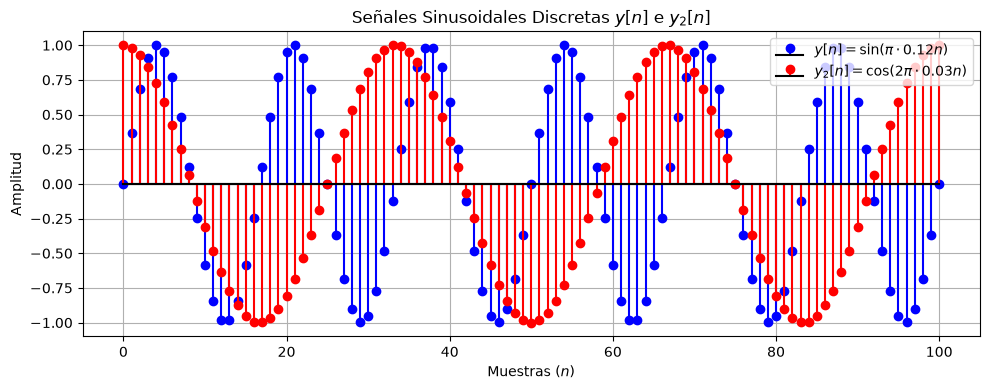

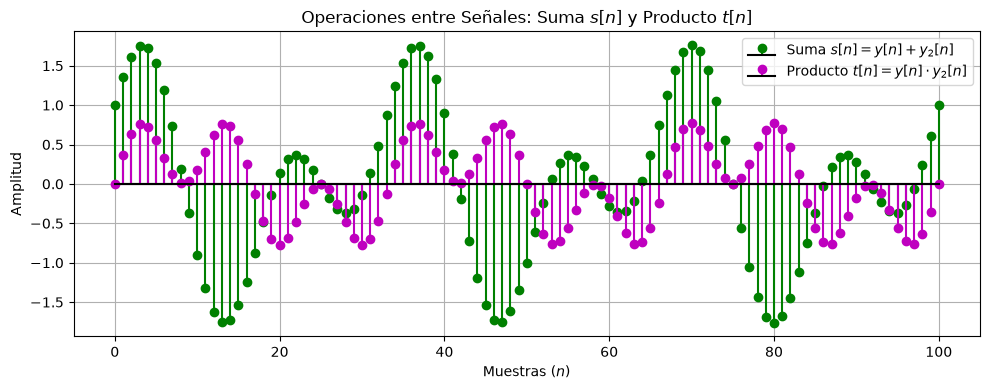

In [9]:
# j) y[n] = sin(pi * 0.12 * n) para 0 <= n <= 100
n = np.arange(0, 101)
y = np.sin(np.pi * 0.12 * n)

# k) y2[n] = cos(2 * pi * 0.03 * n)
y2 = np.cos(2 * np.pi * 0.03 * n)

# l) Suma s[n] y producto t[n]
s = y + y2
t = y * y2

# m) Gráfica conjunta de y[n] e y2[n]
plt.figure(figsize=(10, 4))
plt.stem(n, y, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$y[n] = \sin(\pi \cdot 0.12 n)$')
plt.stem(n, y2, linefmt='r-', markerfmt='ro', basefmt='k-', label=r'$y_2[n] = \cos(2\pi \cdot 0.03 n)$')
plt.title('Señales Sinusoidales Discretas $y[n]$ e $y_2[n]$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# n) Gráfica conjunta de s[n] y t[n]
plt.figure(figsize=(10, 4))
plt.stem(n, s, linefmt='g-', markerfmt='go', basefmt='k-', label='Suma $s[n] = y[n] + y_2[n]$')
plt.stem(n, t, linefmt='m-', markerfmt='mo', basefmt='k-', label=r'Producto $t[n] = y[n] \cdot y_2[n]$')
plt.title('Operaciones entre Señales: Suma $s[n]$ y Producto $t[n]$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Representación de Señales Discretas y Diagramas de Bloques 

En esta sección se hace uso de las funciones elementales (`impseq`, `stepseq`, `rampseq`) para construir señales compuestas y diagramas de bloques de sistemas en tiempo discreto:


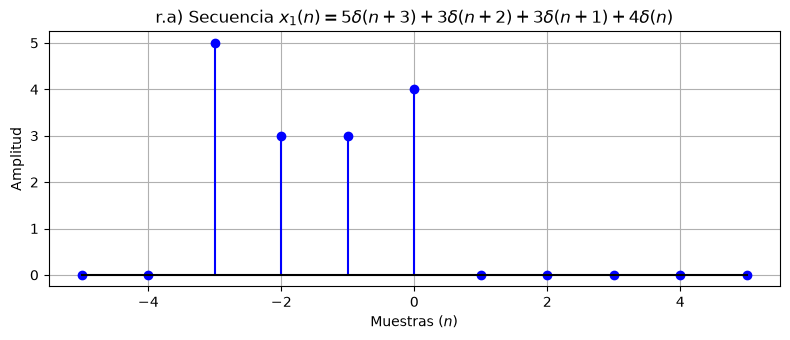

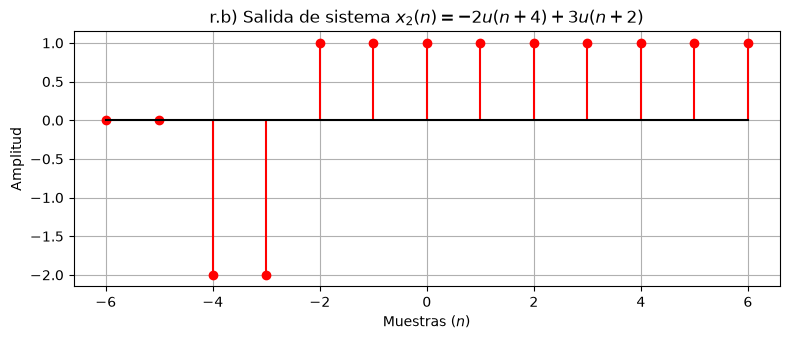

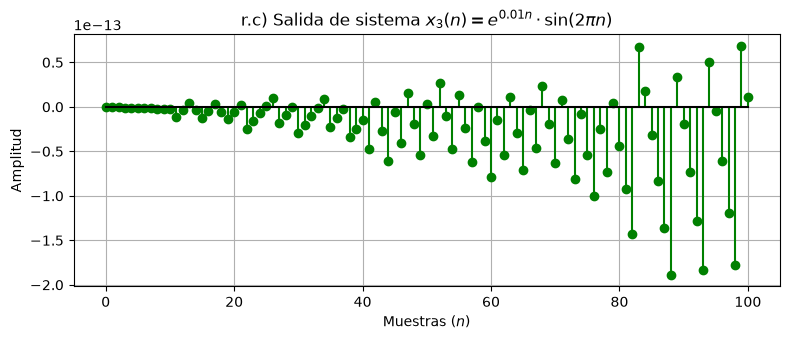

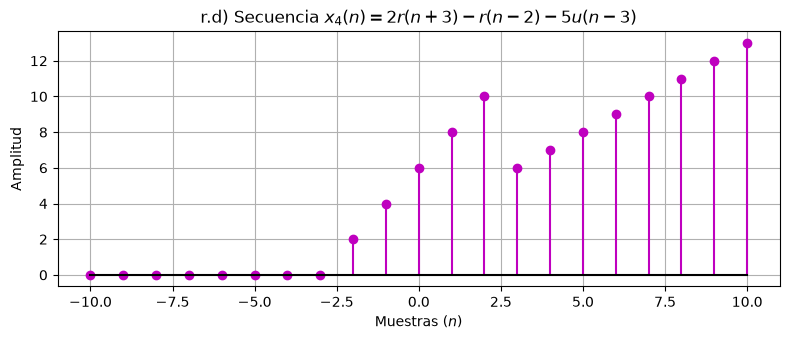

In [10]:
# r.a) x1(n)
# El vector de muestras debe cubrir al menos los índices con amplitudes no nulas (de n = -3 a n = 0).
n_ra = np.arange(-5, 6)
x_d3, _ = impseq(-3, -5, 5)
x_d2, _ = impseq(-2, -5, 5)
x_d1, _ = impseq(-1, -5, 5)
x_d0, _ = impseq(0, -5, 5)
x1 = 5 * x_d3 + 3 * x_d2 + 3 * x_d1 + 4 * x_d0

plt.figure(figsize=(8, 3.5))
plt.stem(n_ra, x1, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title(r'r.a) Secuencia $x_1(n) = 5\delta(n+3) + 3\delta(n+2) + 3\delta(n+1) + 4\delta(n)$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# r.b) Diagrama de bloques: x2(n) = -2*u(n+4) + 3*u(n+2)
u_adv4, n_rb = stepseq(-4, -6, 6)
u_adv2, _ = stepseq(-2, -6, 6)
x2 = -2 * u_adv4 + 3 * u_adv2

plt.figure(figsize=(8, 3.5))
plt.stem(n_rb, x2, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.title('r.b) Salida de sistema $x_2(n) = -2u(n+4) + 3u(n+2)$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# r.c) Diagrama de bloques: x3(n) = exp(0.01*n) * sin(2*pi*n)
n_rc = np.arange(0, 101)
x3 = np.exp(0.01 * n_rc) * np.sin(2 * np.pi * n_rc)

plt.figure(figsize=(8, 3.5))
plt.stem(n_rc, x3, linefmt='g-', markerfmt='go', basefmt='k-')
plt.title(r'r.c) Salida de sistema $x_3(n) = e^{0.01n} \cdot \sin(2\pi n)$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# r.d) x4(n) = 2*r(n+3) - r(n-2) - 5*u(n-3)
r_p3, n_rd = rampseq(-3, -10, 10)
r_m2, _ = rampseq(2, -10, 10)
u_m3, _ = stepseq(3, -10, 10)
x4 = 2 * r_p3 - r_m2 - 5 * u_m3

plt.figure(figsize=(8, 3.5))
plt.stem(n_rd, x4, linefmt='m-', markerfmt='mo', basefmt='k-')
plt.title('r.d) Secuencia $x_4(n) = 2r(n+3) - r(n-2) - 5u(n-3)$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Secuencia Definida a Trozos y Derivada Discreta 

Dada la secuencia periódica a trozos:
$$x[n] = \begin{cases} r[n] & 0 \le n \le 5 \\ r[n-5] & 6 \le n \le 11 \\ r[n-10] & 12 \le n \le 17 \end{cases}$$

Se evalúa la derivada discreta (primera diferencia hacia atrás $\Delta x[n] = x[n] - x[n-1]$) y se comparan los resultados con la derivada del caso continuo.

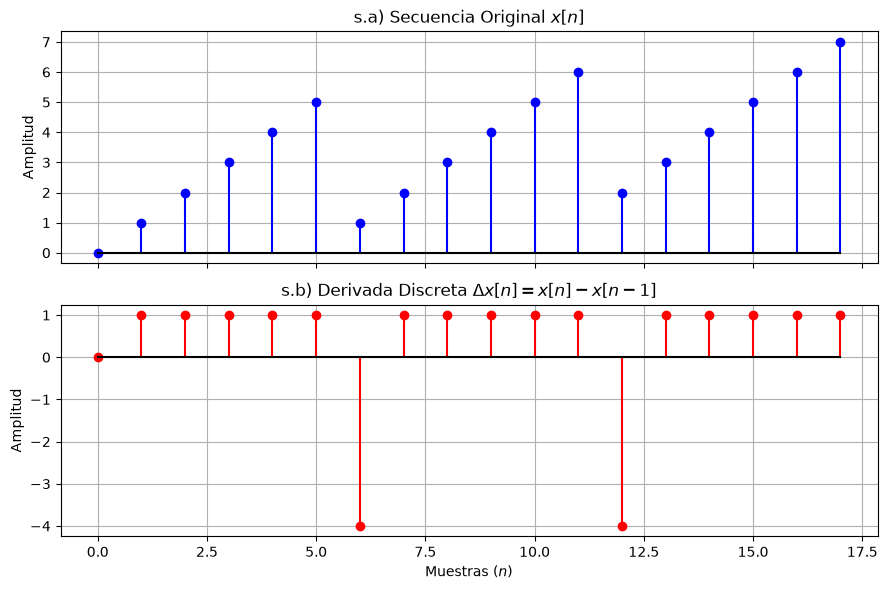

In [5]:
# s.a) Construcción de x[n]
n_s = np.arange(0, 18)
x_s = np.zeros(len(n_s))

for idx, val_n in enumerate(n_s):
    if 0 <= val_n <= 5:
        x_s[idx] = rampseq(0, val_n, val_n)[0][0]
    elif 6 <= val_n <= 11:
        x_s[idx] = rampseq(5, val_n, val_n)[0][0]
    elif 12 <= val_n <= 17:
        x_s[idx] = rampseq(10, val_n, val_n)[0][0]

# Derivada discreta (diferencia finita hacia atrás)
dx_s = np.diff(x_s, prepend=x_s[0])

# s.b) Visualización en subplot
fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].stem(n_s, x_s, linefmt='b-', markerfmt='bo', basefmt='k-')
axs[0].set_title('s.a) Secuencia Original $x[n]$')
axs[0].set_ylabel('Amplitud')
axs[0].grid(True)

axs[1].stem(n_s, dx_s, linefmt='r-', markerfmt='ro', basefmt='k-')
axs[1].set_title('s.b) Derivada Discreta $\\Delta x[n] = x[n] - x[n-1]$')
axs[1].set_xlabel('Muestras ($n$)')
axs[1].set_ylabel('Amplitud')
axs[1].grid(True)
plt.tight_layout()
plt.show()

### Explicación del comportamiento observatorio:
1. **En los tramos continuos creciente ($n \in [1,5], [7,11], [13,17]$)**: La pendiente es constante e igual a 1, por lo que la derivada discreta vale $1$.
2. **En las discontinuidades de salto ($n = 6$ y $n = 12$)**: La señal cae abruptamente de amplitud $5$ a $0$. La diferencia finita resulta en $\Delta x[6] = 0 - 5 = -5$ y $\Delta x[12] = 0 - 5 = -5$.
3. **Diferencia con el caso continuo**: En el dominio continuo, las funciones con saltos finitos presentan derivadas representadas por **impulsos de Dirac de área negativa** ($-5\delta(t-t_0)$). En tiempo discreto, la derivada se aproxima como una muestra puntual de amplitud negativa equivalente al salto de la señal.

## 6. Operaciones y Transformaciones sobre Secuencias Complejas 

Dada la secuencia expresada como vector de valores:
$$x(n) = \{0, 1, 2, 3, 4, \hat{5}, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5, 5, 5, 10, 10, 10, 10, 10\}$$
donde $\hat{5}$ indica la muestra correspondiente a $n=0$ (por lo que el vector abarca el intervalo $-5 \le n \le 17$).

Se generan las transformaciones:

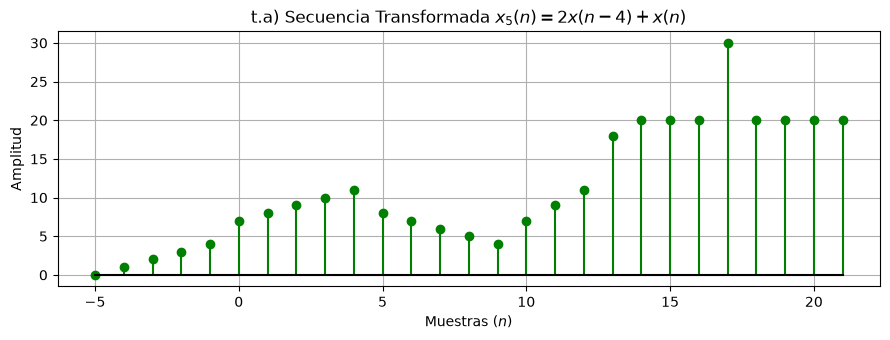

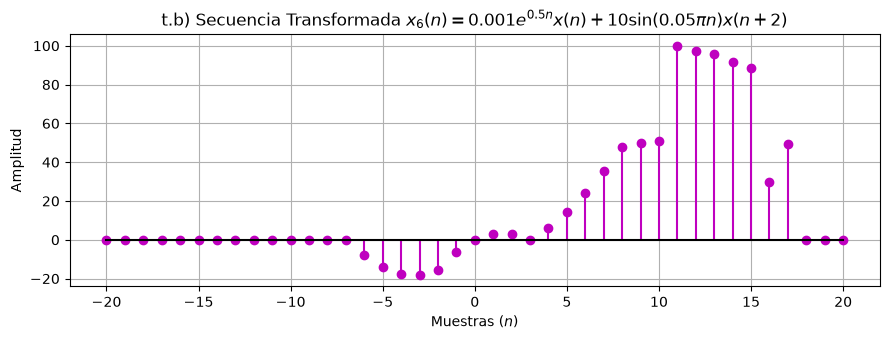

In [13]:
# Definición de la secuencia x(n) alineada con su índice de origen n=0
x_vals = np.array([0, 1, 2, 3, 4, 5, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5, 5, 5, 10, 10, 10, 10, 10], dtype=float)
n_xt = np.arange(-5, len(x_vals) - 5)  # de n = -5 hasta n = 17

# t.a) x5(n) = 2*x(n-4) + x(n)
x_sh4, n_sh4 = sigshift(x_vals, n_xt, 4)
x5, n_x5 = sigadd(2 * x_sh4, n_sh4, x_vals, n_xt)

plt.figure(figsize=(9, 3.5))
plt.stem(n_x5, x5, linefmt='g-', markerfmt='go', basefmt='k-')
plt.title(r't.a) Secuencia Transformada $x_5(n) = 2x(n-4) + x(n)$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# t.b) x6(n) en el intervalo -20 <= n <= 20
n_x6_dom = np.arange(-20, 21)

# Ajustar x(n) al nuevo dominio amplio
x_full = np.zeros(len(n_x6_dom))
x_full[np.isin(n_x6_dom, n_xt)] = x_vals

# Adelanto de x(n+2) alineado
x_p2_sh, n_p2 = sigshift(x_vals, n_xt, -2)
x_p2_full = np.zeros(len(n_x6_dom))
x_p2_full[np.isin(n_x6_dom, n_p2)] = x_p2_sh

# Evaluación del término exponencial y armónico
term1 = 0.001 * np.exp(0.5 * n_x6_dom) * x_full
term2 = 10 * np.sin(0.05 * np.pi * n_x6_dom) * x_p2_full
x6 = term1 + term2

plt.figure(figsize=(9, 3.5))
plt.stem(n_x6_dom, x6, linefmt='m-', markerfmt='mo', basefmt='k-')
plt.title(r't.b) Secuencia Transformada $x_6(n) = 0.001 e^{0.5n} x(n) + 10 \sin(0.05\pi n) x(n+2)$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

## **Repaso Pandas**



In [ ]:
# Ejercicio 1: Demostración de función con un diccionario de calificaciones
notas_alumnos = {
    'Jero': 4.5,
    'Samantha': 3.8,
    'Astolfo': 2.5,
    'Sofia': 4.8,
    'Sthefania': 3.2,
    'Añejandro locurco': 1.9,
    'Yasuri': 3.5
}
print("1) Estadísticas descriptivas de las notas del curso:")
print(calcular_estadisticas_notas(notas_alumnos))

# Ejercicio 2: Procesamiento del dataset de bioseñales datos.csv
df = pd.read_csv('datos.csv', sep=';')

print("\n2.b) Primeras 5 filas del dataset original:")
print(df.head())

print("\n2.b) Últimas 5 filas del dataset original:")
print(df.tail())

# 2.c) Eliminar columna 'Unnamed: 0'
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# 2.d - 2.e) Cálculo e inserción de la columna BMI
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# 2.f) Categorización opcional según IMC
df['Categoria_BMI'] = df['BMI'].apply(categorizar_bmi)

print("\n2.e-f) DataFrame procesado con las columnas 'BMI' y 'Categoria_BMI':")
print(df.head(10))

1) Estadísticas descriptivas de las notas del curso:
Minimo               1.900000
Maximo               4.800000
Media                3.450000
Desviacion_Tipica    1.132696
dtype: float64

2.b) Primeras 5 filas del dataset original:
   Unnamed: 0  Gender  FSIQ  VIQ  PIQ  Weight  Height  MRI_Count
0           1  Female   133  132  124   118.0    64.5     816932
1           3    Male   139  123  150   143.0    73.3    1038437
2           4    Male   133  129  128   172.0    68.8     965353
3           5  Female   137  132  134   147.0    65.0     951545
4           6  Female    99   90  110   146.0    69.0     928799

2.b) Últimas 5 filas del dataset original:
    Unnamed: 0  Gender  FSIQ  VIQ  PIQ  Weight  Height  MRI_Count
33          36  Female   133  129  128   153.0    66.5     948066
34          37    Male   140  150  124   144.0    70.5     949395
35          38  Female    88   86   94   139.0    64.5     893983
36          39    Male    81   90   74   148.0    74.0     930016
37 